# nb28 — CNC + tSZ PS combined vs CNC-only (arnaudB1, Y_R500c)

Two **separate** two-chain comparisons (ω_b fixed D3A throughout):

**CCCP** (`1−b ~ N(0.780, 0.092)`, `B = 1/(1−b)` derived):

| Run | Chain |
|-----|-------|
| CNC only | `chains/cnc_cosmo_arnaudB1_Y500c_cccp/cnc_cosmo` |
| CNC + full-sky PS | `chains/cnc_yy_combined_fullsky_arnaudB1_Y500c/combined` |

**B=1 + fixOb** (`B = 1` fixed):

| Run | Chain |
|-----|-------|
| CNC only | `chains/cnc_cosmo_arnaudB1_Y500c_fixObB1/cnc_cosmo` |
| CNC + full-sky PS | `chains/cnc_yy_combined_fullsky_arnaudB1_Y500c_fixObB1/combined` |

**Uniform B** (`B ~ U(1, 2)`, `α ~ U(0.9, 1.2)`):

| Run | Chain |
|-----|-------|
| CNC only | `chains/cnc_cosmo_arnaudB1_Y500c_uniformB/cnc_cosmo` |
| CNC + full-sky PS | `chains/cnc_yy_combined_fullsky_arnaudB1_Y500c_uniformB/combined` |

**D3A nuisance-only** (cosmology fixed; `α ~ U(0.9, 1.2)`, `B ~ U(1, 2)`, `σ_lnY ~ N(0.173, 0.023)`):

| Run | Chain |
|-----|-------|
| CNC only | `chains/cnc_cosmo_arnaudB1_Y500c_d3aNuisance/cnc_cosmo` |
| CNC + full-sky PS | `chains/cnc_yy_combined_fullsky_arnaudB1_Y500c_d3aNuisance/combined` |

**D3A nuisance-only, B=1.35 CNC selection** (same priors; CNC counts from `N2d_z_q_bin_arnaudB135_Y500c.txt`, N(q>5)=768):

| Run | Chain |
|-----|-------|
| CNC only | `chains/cnc_cosmo_arnaudB135_Y500c_d3aNuisance/cnc_cosmo` |
| CNC + full-sky PS | `chains/cnc_yy_combined_fullsky_arnaudB135_Y500c_d3aNuisance/combined` |

**Fixed (cosmo runs):** `A_SZ`, `ω_b` (D3A); cosmology sampled or fixed per section above.
**S8** / **F** derived when cosmology is in the chain.

In [24]:
import os
os.environ["XLA_FLAGS"] = "--xla_profile_fraction=0.10"

import numpy as np
import matplotlib.pyplot as plt

# Publication-quality plot defaults
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

from getdist import loadMCSamples, plots

REPO = "/scratch/scratch-lxu/flamingo_repo"
OUTDIR = os.path.join(REPO, "figures", "nb28_cnc_yy_combined_contours")
os.makedirs(OUTDIR, exist_ok=True)

N_Y500C = 2023
N_Y500C_B135 = 768   # q>5, Y_R500c catalogue with B=1.35 selection
OM_TRUTH, S8_TRUTH = 0.306, 0.808
A_SZ_FIXED = -4.28739604
LOAD_SETTINGS = {"ignore_rows": 0.1}
MIN_SAMPLES_WARN = 200
R1_TARGET = 0.05

RUNS = [
    dict(
        tag="cnc_cccp",
        path=os.path.join(REPO, "chains", "cnc_cosmo_arnaudB1_Y500c_cccp", "cnc_cosmo"),
        label="CNC only (CCCP)",
        color="#2ca02c",
        run_hint="bash cobaya/run_cnc_cosmo_B1_Y500c_cccp.sh",
    ),
    dict(
        tag="comb_cccp",
        path=os.path.join(REPO, "chains", "cnc_yy_combined_fullsky_arnaudB1_Y500c", "combined"),
        label="CNC + full-sky PS (CCCP)",
        color="#9467bd",
        run_hint="bash cobaya/run_cnc_yy_combined_fullsky_B1_Y500c.sh",
    ),
    dict(
        tag="cnc_b1",
        path=os.path.join(REPO, "chains", "cnc_cosmo_arnaudB1_Y500c_fixObB1", "cnc_cosmo"),
        label="CNC only (B=1)",
        color="#1f77b4",
        run_hint="bash cobaya/run_cnc_cosmo_B1_Y500c_fixObB1.sh",
    ),
    dict(
        tag="comb_b1",
        path=os.path.join(REPO, "chains", "cnc_yy_combined_fullsky_arnaudB1_Y500c_fixObB1", "combined"),
        label="CNC + full-sky PS (B=1)",
        color="#ff7f0e",
        run_hint="bash cobaya/run_cnc_yy_combined_fullsky_B1_Y500c_fixObB1.sh",
    ),
    dict(
        tag="cnc_unifB",
        path=os.path.join(REPO, "chains", "cnc_cosmo_arnaudB1_Y500c_uniformB", "cnc_cosmo"),
        label="CNC only (B uniform)",
        color="#d62728",
        run_hint="bash cobaya/run_cnc_cosmo_B1_Y500c_uniformB.sh",
    ),
    dict(
        tag="comb_unifB",
        path=os.path.join(REPO, "chains", "cnc_yy_combined_fullsky_arnaudB1_Y500c_uniformB", "combined"),
        label="CNC + full-sky PS (B uniform)",
        color="#8c564b",
        run_hint="bash cobaya/run_cnc_yy_combined_fullsky_B1_Y500c_uniformB.sh",
    ),
    dict(
        tag="cnc_d3a",
        path=os.path.join(REPO, "chains", "cnc_cosmo_arnaudB1_Y500c_d3aNuisance", "cnc_cosmo"),
        label="CNC only (D3A nuisance)",
        color="#e377c2",
        run_hint="bash cobaya/run_cnc_cosmo_B1_Y500c_d3aNuisance.sh",
    ),
    dict(
        tag="comb_d3a",
        path=os.path.join(REPO, "chains", "cnc_yy_combined_fullsky_arnaudB1_Y500c_d3aNuisance", "combined"),
        label="CNC + full-sky PS (D3A nuisance)",
        color="#bcbd22",
        run_hint="bash cobaya/run_cnc_yy_combined_fullsky_B1_Y500c_d3aNuisance.sh",
    ),
    dict(
        tag="cnc_d3a_b135",
        path=os.path.join(REPO, "chains", "cnc_cosmo_arnaudB135_Y500c_d3aNuisance", "cnc_cosmo"),
        label="CNC only (D3A nuisance, B=1.35 sel.)",
        color="#17becf",
        run_hint="bash cobaya/run_cnc_cosmo_B135_Y500c_d3aNuisance.sh",
    ),
    dict(
        tag="comb_d3a_b135",
        path=os.path.join(REPO, "chains", "cnc_yy_combined_fullsky_arnaudB135_Y500c_d3aNuisance", "combined"),
        label="CNC + full-sky PS (D3A nuisance, B=1.35 sel.)",
        color="#aec7e8",
        run_hint="bash cobaya/run_cnc_yy_combined_fullsky_B135_Y500c_d3aNuisance.sh",
    ),
]

TRUTH = {
    "Omega_m": 0.306, "sigma8": S8_TRUTH,
    "S8": S8_TRUTH * np.sqrt(0.306 / 0.3),
    "F": S8_TRUTH * (0.306 / 1.1) ** 0.40 * 0.681 ** (-0.21),
    "h": 0.681, "omega_b": 0.022539, "n_s": 0.967,
    "alpha_SZ": 1.12, "one_minus_b": 0.780, "sigma_lnY": 0.173, "B": 1.0,
}
CCCP_TAGS = ("cnc_cccp", "comb_cccp")
B1_TAGS = ("cnc_b1", "comb_b1")
UNIFB_TAGS = ("cnc_unifB", "comb_unifB")
D3A_NUISANCE_TAGS = ("cnc_d3a", "comb_d3a")
D3A_B135_NUISANCE_TAGS = ("cnc_d3a_b135", "comb_d3a_b135")
ALL_D3A_NUISANCE_TAGS = D3A_NUISANCE_TAGS + D3A_B135_NUISANCE_TAGS
D3A_N_OBS = {
    "cnc_d3a": N_Y500C, "comb_d3a": N_Y500C,
    "cnc_d3a_b135": N_Y500C_B135, "comb_d3a_b135": N_Y500C_B135,
}
CCCP_CHAIN_PARS = ["Omega_m", "sigma8", "h", "n_s", "alpha_SZ", "one_minus_b", "sigma_lnY"]
B1_CHAIN_PARS = ["Omega_m", "sigma8", "h", "n_s", "alpha_SZ", "sigma_lnY"]
UNIFB_CHAIN_PARS = ["Omega_m", "sigma8", "h", "n_s", "alpha_SZ", "B", "sigma_lnY"]
D3A_NUISANCE_PARS = ["alpha_SZ", "B", "sigma_lnY"]
D3A_COSMO_FIXED = {
    "sigma8": 0.811, "omega_cdm": 0.118729, "omega_b": 0.022539,
    "h": 0.681, "n_s": 0.967, "A_SZ": A_SZ_FIXED,
}
FIXED_PARS = {"A_SZ": A_SZ_FIXED, "omega_b": 0.022539}
DERIVED_PARS = ["S8", "F"]
COSMO_PARS = ["Omega_m", "sigma8", "S8", "F"]
PARS_PRINT = CCCP_CHAIN_PARS[:2] + DERIVED_PARS + CCCP_CHAIN_PARS[2:]


def _resolve_B(sample):
    """B may be sampled, derived (CCCP), or fixed absent from chain (fixObB1)."""
    names = set(sample.getParamNames().list())
    p = sample.getParams()
    if "B" in names:
        return p.B
    if "one_minus_b" in names:
        return 1.0 / p.one_minus_b
    return 1.0


def _add_derived(sample):
    names = set(sample.getParamNames().list())
    if "sigma8" not in names or "Omega_m" not in names:
        return sample
    p = sample.getParams()
    B = _resolve_B(sample)
    sample.addDerived(
        p.sigma8 * np.sqrt(p.Omega_m / 0.3), name="S8", label=r"S_8",
    )
    sample.addDerived(
        p.sigma8 * (p.Omega_m / B) ** 0.40 * p.h ** (-0.21), name="F", label=r"F",
    )
    return sample


def _print_d3a_posterior(sample, title):
    print(title)
    for nm in D3A_NUISANCE_PARS:
        print(f"  {nm:12s} = {sample.mean(nm):.4f} +/- {sample.std(nm):.4f}")
    for nm, val in D3A_COSMO_FIXED.items():
        print(f"  {nm:12s} = {val:.6f} (fixed D3A)")


def _print_posterior(sample, title, fixed_extra=None):
    names = set(sample.getParamNames().list())
    print(title)
    for nm in PARS_PRINT:
        if nm in names:
            print(f"  {nm:12s} = {sample.mean(nm):.4f} +/- {sample.std(nm):.4f}")
        elif nm != "one_minus_b":
            print(f"  {nm:12s} = (missing from chain)")
    for nm, val in FIXED_PARS.items():
        print(f"  {nm:12s} = {val:.6f} (fixed)")
    if fixed_extra:
        for nm, val in fixed_extra.items():
            print(f"  {nm:12s} = {val:.6f} (fixed)")


def _read_rminus1(path):
    ckpt = path + ".checkpoint"
    if not os.path.exists(ckpt):
        return None
    for line in open(ckpt):
        if "Rminus1_last:" in line:
            return float(line.split(":", 1)[1].strip())
    return None


def _load_chain(path, label, run_hint):
    chain_file = path + ".1.txt"
    if not os.path.exists(chain_file):
        print(f"\n{label} chain not ready: {chain_file}")
        print(f"  run: {run_hint}")
        return None
    sample = _add_derived(loadMCSamples(path, settings=LOAD_SETTINGS))
    r1 = _read_rminus1(path)
    print(f"\n{label}: {sample.numrows} post-discard samples", end="")
    if r1 is not None:
        flag = " (converged)" if r1 <= R1_TARGET else " (running)"
        print(f"; R-1={r1:.3f}{flag}", end="")
    print()
    if sample.numrows < MIN_SAMPLES_WARN:
        print(f"  WARNING: fewer than {MIN_SAMPLES_WARN} samples — chain likely still running.")
    return sample


loaded = {}
for run in RUNS:
    s = _load_chain(run["path"], run["label"], run["run_hint"])
    if s is not None:
        if run["tag"] in ALL_D3A_NUISANCE_TAGS:
            _print_d3a_posterior(s, f"\n{run['label']} — Y_R500c (N={D3A_N_OBS[run['tag']]} ):")
        else:
            fixed_extra = {"B": 1.0} if run["tag"].endswith("_b1") else None
            _print_posterior(s, f"\n{run['label']} — Y_R500c (N={N_Y500C}):", fixed_extra=fixed_extra)
        loaded[run["tag"]] = s

if "cnc_cccp" in loaded and "comb_cccp" in loaded:
    s_cnc, s_comb = loaded["cnc_cccp"], loaded["comb_cccp"]
    print(f"\n[CCCP] ΔS8 (comb − CNC) = {s_comb.mean('S8') - s_cnc.mean('S8'):+.4f}")
    print(f"[CCCP] Δ(1−b) (comb − CNC) = {s_comb.mean('one_minus_b') - s_cnc.mean('one_minus_b'):+.4f}")
if "cnc_b1" in loaded and "comb_b1" in loaded:
    s_cnc, s_comb = loaded["cnc_b1"], loaded["comb_b1"]
    print(f"\n[B=1] ΔS8 (comb − CNC) = {s_comb.mean('S8') - s_cnc.mean('S8'):+.4f}")
if "cnc_unifB" in loaded and "comb_unifB" in loaded:
    s_cnc, s_comb = loaded["cnc_unifB"], loaded["comb_unifB"]
    print(f"\n[B~U(1,2)] ΔS8 (comb − CNC) = {s_comb.mean('S8') - s_cnc.mean('S8'):+.4f}")
    print(f"[B~U(1,2)] ΔB  (comb − CNC) = {s_comb.mean('B') - s_cnc.mean('B'):+.4f}")
if "cnc_d3a" in loaded and "comb_d3a" in loaded:
    s_cnc, s_comb = loaded["cnc_d3a"], loaded["comb_d3a"]
    print(f"\n[D3A nuisance, B=1 sel.] ΔB  (comb − CNC) = {s_comb.mean('B') - s_cnc.mean('B'):+.4f}")
    print(f"[D3A nuisance, B=1 sel.] Δα  (comb − CNC) = {s_comb.mean('alpha_SZ') - s_cnc.mean('alpha_SZ'):+.4f}")
    print(f"[D3A nuisance, B=1 sel.] Δσ  (comb − CNC) = {s_comb.mean('sigma_lnY') - s_cnc.mean('sigma_lnY'):+.4f}")
if "cnc_d3a_b135" in loaded and "comb_d3a_b135" in loaded:
    s_cnc, s_comb = loaded["cnc_d3a_b135"], loaded["comb_d3a_b135"]
    print(f"\n[D3A nuisance, B=1.35 sel.] ΔB  (comb − CNC) = {s_comb.mean('B') - s_cnc.mean('B'):+.4f}")
    print(f"[D3A nuisance, B=1.35 sel.] Δα  (comb − CNC) = {s_comb.mean('alpha_SZ') - s_cnc.mean('alpha_SZ'):+.4f}")
    print(f"[D3A nuisance, B=1.35 sel.] Δσ  (comb − CNC) = {s_comb.mean('sigma_lnY') - s_cnc.mean('sigma_lnY'):+.4f}")

print(f"\nFLAMINGO truth: Omega_m={OM_TRUTH}, sigma8={S8_TRUTH}, "
      f"S8={S8_TRUTH * np.sqrt(OM_TRUTH / 0.3):.3f}")


def _common_params(chains, wanted):
    names = [set(s.getParamNames().list()) for s in chains]
    common = [p for p in wanted if all(p in n for n in names)]
    omitted = [p for p in wanted if p not in common]
    if omitted:
        print(f"Plot params omitted (missing in some chain): {omitted}")
    return common


def _select_group(tags):
    runs = [r for r in RUNS if r["tag"] in tags and r["tag"] in loaded]
    return (
        [loaded[r["tag"]] for r in runs],
        [r["label"] for r in runs],
        [r["color"] for r in runs],
    )


def _plot_pars(chain_pars, chains):
    if len(chains) < 2:
        return [], []
    full = chain_pars[:2] + DERIVED_PARS + chain_pars[2:]
    return _common_params(chains, full), _common_params(chains, COSMO_PARS)


cccp_chains, cccp_labels, cccp_colors = _select_group(CCCP_TAGS)
b1_chains, b1_labels, b1_colors = _select_group(B1_TAGS)
unifB_chains, unifB_labels, unifB_colors = _select_group(UNIFB_TAGS)
d3a_chains, d3a_labels, d3a_colors = _select_group(D3A_NUISANCE_TAGS)
d3a_b135_chains, d3a_b135_labels, d3a_b135_colors = _select_group(D3A_B135_NUISANCE_TAGS)
cccp_pars, cccp_cosmo_pars = _plot_pars(CCCP_CHAIN_PARS, cccp_chains)
b1_pars, b1_cosmo_pars = _plot_pars(B1_CHAIN_PARS, b1_chains)
unifB_pars, unifB_cosmo_pars = _plot_pars(UNIFB_CHAIN_PARS, unifB_chains)
d3a_pars = _common_params(d3a_chains, D3A_NUISANCE_PARS) if len(d3a_chains) >= 2 else []
d3a_b135_pars = _common_params(d3a_b135_chains, D3A_NUISANCE_PARS) if len(d3a_b135_chains) >= 2 else []

if not (cccp_chains or b1_chains or unifB_chains or d3a_chains or d3a_b135_chains):
    raise RuntimeError("No chain files found — start at least one Cobaya run first.")




CNC only (CCCP): 5940 post-discard samples; R-1=0.039 (converged)

CNC only (CCCP) — Y_R500c (N=2023):
  Omega_m      = 0.3038 +/- 0.0129
  sigma8       = 0.8170 +/- 0.0249
  S8           = 0.8220 +/- 0.0310
  F            = 0.4988 +/- 0.0029
  h            = 0.6748 +/- 0.0227
  n_s          = 0.9666 +/- 0.0136
  alpha_SZ     = 1.0987 +/- 0.0459
  one_minus_b  = 0.7851 +/- 0.0781
  sigma_lnY    = 0.1757 +/- 0.0234
  A_SZ         = -4.287396 (fixed)
  omega_b      = 0.022539 (fixed)

CNC + full-sky PS (CCCP): 3852 post-discard samples; R-1=0.042 (converged)

CNC + full-sky PS (CCCP) — Y_R500c (N=2023):
  Omega_m      = 0.2691 +/- 0.0095
  sigma8       = 0.7629 +/- 0.0177
  S8           = 0.7222 +/- 0.0134
  F            = 0.5106 +/- 0.0023
  h            = 0.6806 +/- 0.0235
  n_s          = 0.9669 +/- 0.0139
  alpha_SZ     = 1.0421 +/- 0.0402
  one_minus_b  = 1.1152 +/- 0.0535
  sigma_lnY    = 0.1788 +/- 0.0222
  A_SZ         = -4.287396 (fixed)
  omega_b      = 0.022539 (fixed)

CNC o

## CCCP (`1−b` sampled): triangle — all parameters

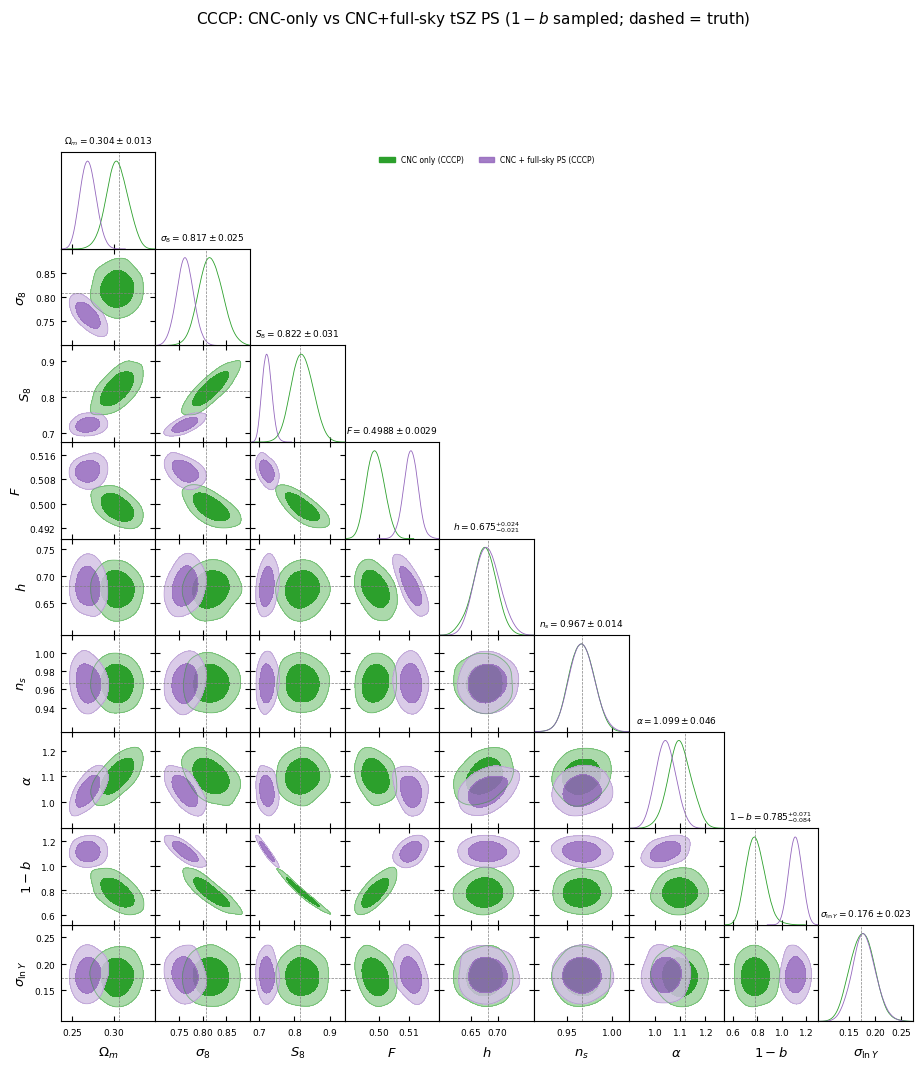

In [25]:
if len(cccp_chains) >= 2 and cccp_pars:
    g = plots.get_subplot_plotter(width_inch=11)
    g.settings.legend_fontsize = 10
    g.settings.figure_legend_frame = False
    g.triangle_plot(
        cccp_chains, cccp_pars, filled=True, contour_colors=cccp_colors,
        legend_labels=cccp_labels, legend_loc="upper center", legend_ncol=2,
        title_limit=1, markers={k: TRUTH[k] for k in cccp_pars if k in TRUTH},
    )
    g.fig.suptitle(
        r"CCCP: CNC-only vs CNC+full-sky tSZ PS ($1-b$ sampled; dashed = truth)",
        fontsize=11, y=1.03,
    )
    g.fig.subplots_adjust(top=0.90)
    g.export(os.path.join(OUTDIR, "cccp_triangle_all.pdf"))
    g.export(os.path.join(OUTDIR, "cccp_triangle_all.png", dpi=300))
    plt.show()
else:
    print("CCCP triangle skipped (need both CCCP chains).")


## CCCP: cosmology + F

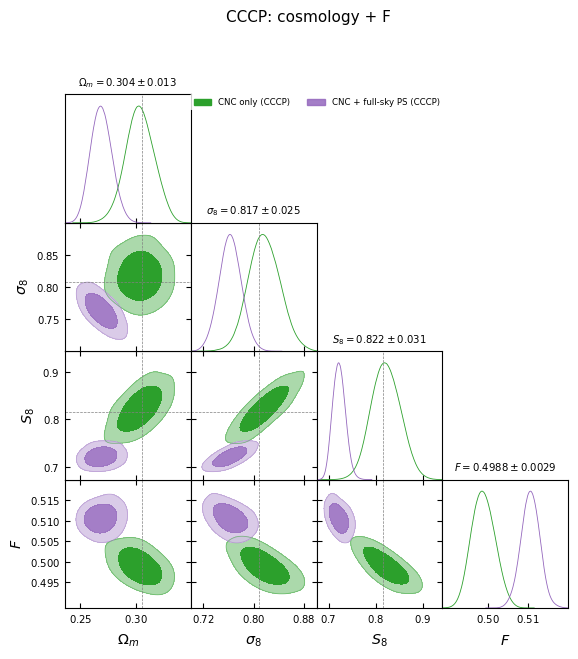

In [26]:
if len(cccp_chains) >= 2 and cccp_cosmo_pars:
    g_cos = plots.get_subplot_plotter(width_inch=6.5)
    g_cos.settings.legend_fontsize = 10
    g_cos.settings.figure_legend_frame = False
    g_cos.triangle_plot(
        cccp_chains, cccp_cosmo_pars, filled=True, contour_colors=cccp_colors,
        legend_labels=cccp_labels, legend_loc="upper center", legend_ncol=2,
        title_limit=1, markers={k: TRUTH[k] for k in cccp_cosmo_pars if k in TRUTH},
    )
    g_cos.fig.suptitle(r"CCCP: cosmology + F", fontsize=11, y=1.03)
    g_cos.fig.subplots_adjust(top=0.90)
    g_cos.export(os.path.join(OUTDIR, "cccp_triangle_cosmo.pdf"))
    g_cos.export(os.path.join(OUTDIR, "cccp_triangle_cosmo.png", dpi=300))
    plt.show()
else:
    print("CCCP cosmology panel skipped.")


## CCCP: $\Omega_m$–$\sigma_8$ plane

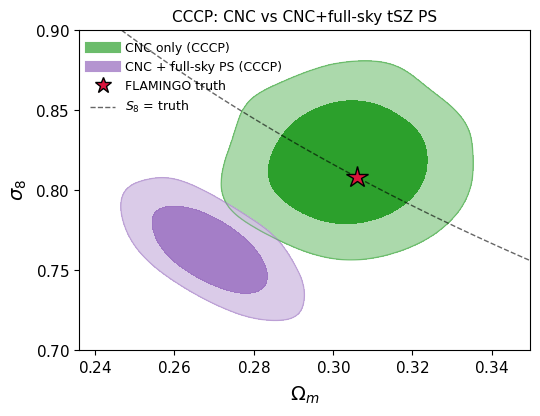

In [27]:
from matplotlib.lines import Line2D

if len(cccp_chains) >= 2:
    g2 = plots.get_single_plotter(width_inch=5.5)
    g2.plot_2d(cccp_chains, "Omega_m", "sigma8", filled=True, colors=cccp_colors)
    ax = g2.get_axes()
    ax.plot(OM_TRUTH, S8_TRUTH, "*", color="crimson", ms=16, mec="k", zorder=5)
    om = np.linspace(*ax.get_xlim(), 50)
    S8t = S8_TRUTH * np.sqrt(OM_TRUTH / 0.3)
    ax.plot(om, S8t / np.sqrt(om / 0.3), "k--", lw=1, alpha=0.6)
    handles = [
        Line2D([], [], color=c, lw=8, alpha=0.7, label=l)
        for c, l in zip(cccp_colors, cccp_labels)
    ]
    handles += [
        Line2D([], [], color="crimson", marker="*", ls="", ms=12, mec="k", label="FLAMINGO truth"),
        Line2D([], [], color="k", ls="--", lw=1, alpha=0.6, label=r"$S_8$ = truth"),
    ]
    ax.legend(handles=handles, fontsize=9, loc="upper left", frameon=False)
    ax.set_title(r"CCCP: CNC vs CNC+full-sky tSZ PS", fontsize=11)
    g2.export(os.path.join(OUTDIR, "cccp_Om_s8_plane.pdf"))
    g2.export(os.path.join(OUTDIR, "cccp_Om_s8_plane.png", dpi=300))
    plt.show()
else:
    print("CCCP Ωm–σ8 panel skipped.")


## B=1 + fixOb: triangle — all parameters

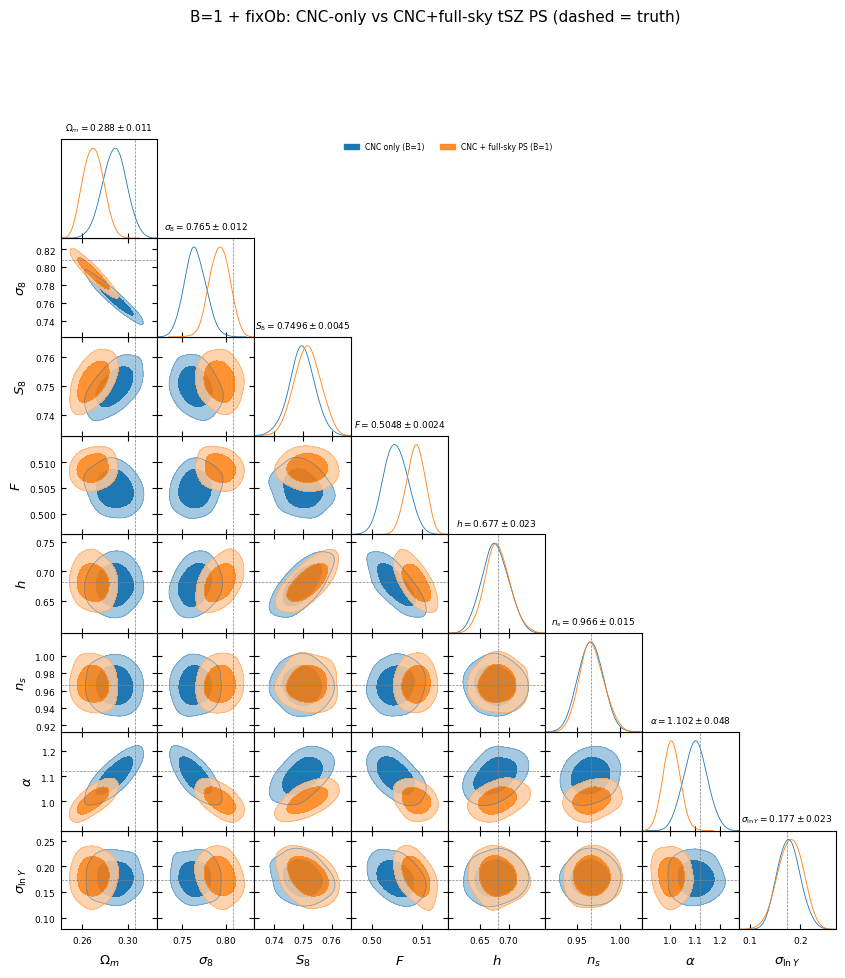

In [28]:
if len(b1_chains) >= 2 and b1_pars:
    g_b1 = plots.get_subplot_plotter(width_inch=10)
    g_b1.settings.legend_fontsize = 10
    g_b1.settings.figure_legend_frame = False
    g_b1.triangle_plot(
        b1_chains, b1_pars, filled=True, contour_colors=b1_colors,
        legend_labels=b1_labels, legend_loc="upper center", legend_ncol=2,
        title_limit=1, markers={k: TRUTH[k] for k in b1_pars if k in TRUTH},
    )
    g_b1.fig.suptitle(
        r"B=1 + fixOb: CNC-only vs CNC+full-sky tSZ PS (dashed = truth)",
        fontsize=11, y=1.03,
    )
    g_b1.fig.subplots_adjust(top=0.90)
    g_b1.export(os.path.join(OUTDIR, "b1_triangle_all.pdf"))
    g_b1.export(os.path.join(OUTDIR, "b1_triangle_all.png", dpi=300))
    plt.show()
else:
    print("B=1 triangle skipped (need both fixObB1 chains).")


## B=1 + fixOb: cosmology + F

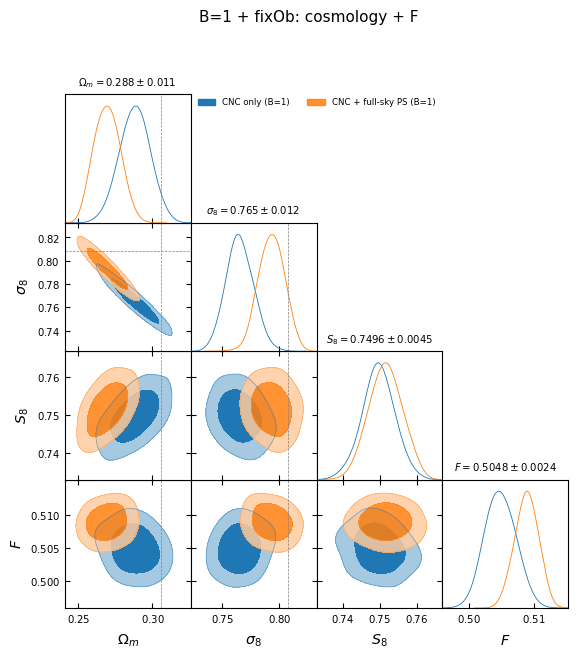

In [29]:
if len(b1_chains) >= 2 and b1_cosmo_pars:
    g_b1c = plots.get_subplot_plotter(width_inch=6.5)
    g_b1c.settings.legend_fontsize = 10
    g_b1c.settings.figure_legend_frame = False
    g_b1c.triangle_plot(
        b1_chains, b1_cosmo_pars, filled=True, contour_colors=b1_colors,
        legend_labels=b1_labels, legend_loc="upper center", legend_ncol=2,
        title_limit=1, markers={k: TRUTH[k] for k in b1_cosmo_pars if k in TRUTH},
    )
    g_b1c.fig.suptitle(r"B=1 + fixOb: cosmology + F", fontsize=11, y=1.03)
    g_b1c.fig.subplots_adjust(top=0.90)
    g_b1c.export(os.path.join(OUTDIR, "b1_triangle_cosmo.pdf"))
    g_b1c.export(os.path.join(OUTDIR, "b1_triangle_cosmo.png", dpi=300))
    plt.show()
else:
    print("B=1 cosmology panel skipped.")


## B=1 + fixOb: $\Omega_m$–$\sigma_8$ plane

saved -> /scratch/scratch-lxu/flamingo_repo/figures/nb28_cnc_yy_combined_contours


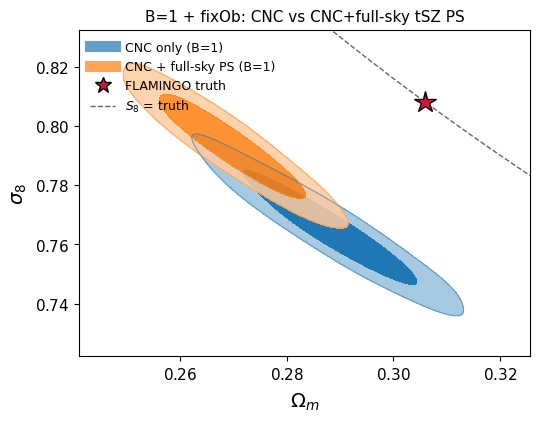

In [30]:
from matplotlib.lines import Line2D

if len(b1_chains) >= 2:
    g_b1o = plots.get_single_plotter(width_inch=5.5)
    g_b1o.plot_2d(b1_chains, "Omega_m", "sigma8", filled=True, colors=b1_colors)
    ax = g_b1o.get_axes()
    ax.plot(OM_TRUTH, S8_TRUTH, "*", color="crimson", ms=16, mec="k", zorder=5)
    om = np.linspace(*ax.get_xlim(), 50)
    S8t = S8_TRUTH * np.sqrt(OM_TRUTH / 0.3)
    ax.plot(om, S8t / np.sqrt(om / 0.3), "k--", lw=1, alpha=0.6)
    handles = [
        Line2D([], [], color=c, lw=8, alpha=0.7, label=l)
        for c, l in zip(b1_colors, b1_labels)
    ]
    handles += [
        Line2D([], [], color="crimson", marker="*", ls="", ms=12, mec="k", label="FLAMINGO truth"),
        Line2D([], [], color="k", ls="--", lw=1, alpha=0.6, label=r"$S_8$ = truth"),
    ]
    ax.legend(handles=handles, fontsize=9, loc="upper left", frameon=False)
    ax.set_title(r"B=1 + fixOb: CNC vs CNC+full-sky tSZ PS", fontsize=11)
    g_b1o.export(os.path.join(OUTDIR, "b1_Om_s8_plane.pdf"))
    g_b1o.export(os.path.join(OUTDIR, "b1_Om_s8_plane.png", dpi=300))
    print("saved ->", OUTDIR)
    plt.show()
else:
    print("B=1 Ωm–σ8 panel skipped.")


## B ~ U(1, 2): CNC vs CNC+full-sky PS

In [31]:
# Triangle (cosmology + nuisances incl. B) in the next cell.

### Triangle: all sampled parameters (incl. B, α, σ_lnY)

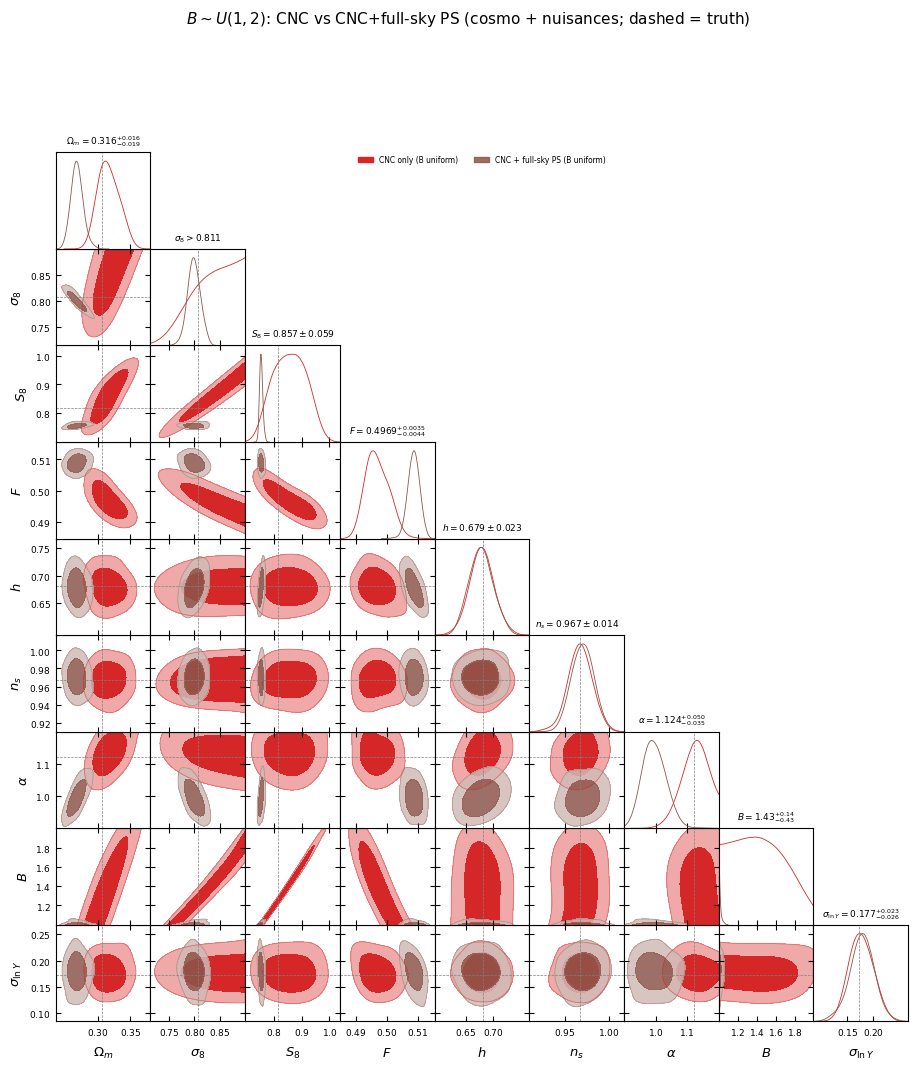

In [32]:
if len(unifB_chains) >= 2 and unifB_pars:
    g_ubc = plots.get_subplot_plotter(width_inch=11)
    g_ubc.settings.legend_fontsize = 10
    g_ubc.settings.figure_legend_frame = False
    g_ubc.triangle_plot(
        unifB_chains, unifB_pars, filled=True, contour_colors=unifB_colors,
        legend_labels=unifB_labels, legend_loc="upper center", legend_ncol=2,
        title_limit=1, markers={k: TRUTH[k] for k in unifB_pars if k in TRUTH},
    )
    g_ubc.fig.suptitle(
        r"$B \sim U(1,2)$: CNC vs CNC+full-sky PS (cosmo + nuisances; dashed = truth)",
        fontsize=11, y=1.03,
    )
    g_ubc.fig.subplots_adjust(top=0.90)
    g_ubc.export(os.path.join(OUTDIR, "uniformB_triangle_cosmo_nuisance.pdf"))
    g_ubc.export(os.path.join(OUTDIR, "uniformB_triangle_cosmo_nuisance.png", dpi=300))
    plt.show()
else:
    print("Uniform-B cosmo+nuisance triangle skipped (need both uniformB chains).")


## B ~ U(1, 2): $\Omega_m$–$\sigma_8$ plane

saved -> /scratch/scratch-lxu/flamingo_repo/figures/nb28_cnc_yy_combined_contours


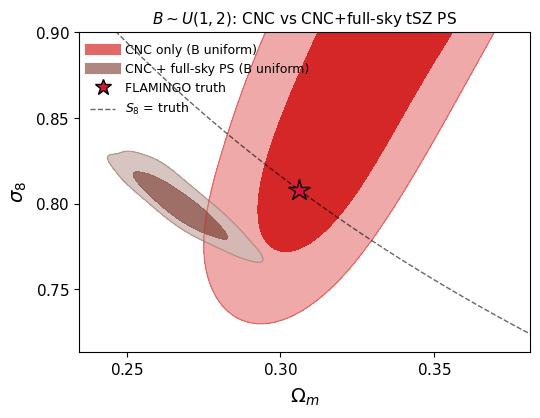

In [33]:
from matplotlib.lines import Line2D

if len(unifB_chains) >= 2:
    g_ubo = plots.get_single_plotter(width_inch=5.5)
    g_ubo.plot_2d(unifB_chains, "Omega_m", "sigma8", filled=True, colors=unifB_colors)
    ax = g_ubo.get_axes()
    ax.plot(OM_TRUTH, S8_TRUTH, "*", color="crimson", ms=16, mec="k", zorder=5)
    om = np.linspace(*ax.get_xlim(), 50)
    S8t = S8_TRUTH * np.sqrt(OM_TRUTH / 0.3)
    ax.plot(om, S8t / np.sqrt(om / 0.3), "k--", lw=1, alpha=0.6)
    handles = [
        Line2D([], [], color=c, lw=8, alpha=0.7, label=l)
        for c, l in zip(unifB_colors, unifB_labels)
    ]
    handles += [
        Line2D([], [], color="crimson", marker="*", ls="", ms=12, mec="k", label="FLAMINGO truth"),
        Line2D([], [], color="k", ls="--", lw=1, alpha=0.6, label=r"$S_8$ = truth"),
    ]
    ax.legend(handles=handles, fontsize=9, loc="upper left", frameon=False)
    ax.set_title(r"$B \sim U(1,2)$: CNC vs CNC+full-sky tSZ PS", fontsize=11)
    g_ubo.export(os.path.join(OUTDIR, "uniformB_Om_s8_plane.pdf"))
    g_ubo.export(os.path.join(OUTDIR, "uniformB_Om_s8_plane.png", dpi=300))
    print("saved ->", OUTDIR)
    plt.show()
else:
    print("Uniform-B Ωm–σ8 panel skipped.")


## D3A fixed: nuisance posteriors (`α`, `B`, `σ_lnY` only)

Cosmology fixed at D3A; uniform priors on `α` and `B`, Gaussian on `σ_lnY`.

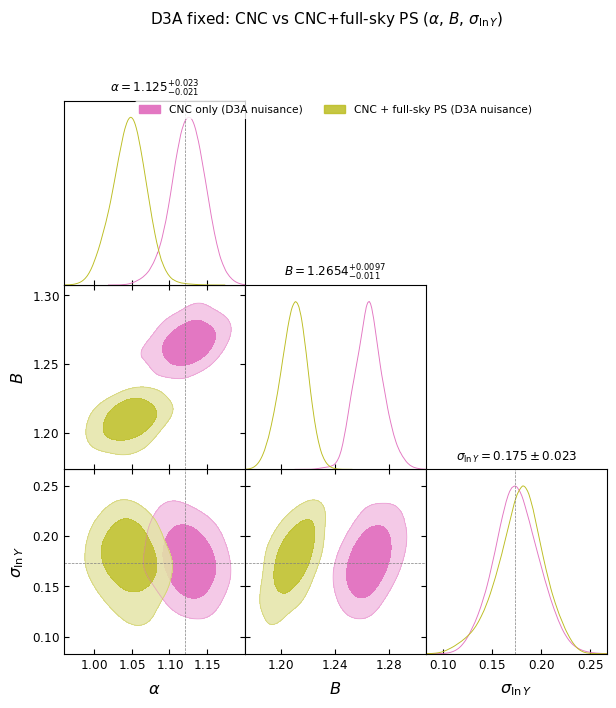

In [34]:
if len(d3a_chains) >= 2 and d3a_pars:
    g_d3a = plots.get_subplot_plotter(width_inch=7)
    g_d3a.settings.legend_fontsize = 10
    g_d3a.settings.figure_legend_frame = False
    d3a_truth = {k: TRUTH[k] for k in d3a_pars if k in TRUTH}
    g_d3a.triangle_plot(
        d3a_chains, d3a_pars, filled=True, contour_colors=d3a_colors,
        legend_labels=d3a_labels, legend_loc="upper center", legend_ncol=2,
        title_limit=1, markers=d3a_truth,
    )
    g_d3a.fig.suptitle(
        r"D3A fixed: CNC vs CNC+full-sky PS ($\alpha$, $B$, $\sigma_{\ln Y}$)",
        fontsize=11, y=1.03,
    )
    g_d3a.fig.subplots_adjust(top=0.90)
    g_d3a.export(os.path.join(OUTDIR, "d3a_nuisance_triangle.pdf"))
    g_d3a.export(os.path.join(OUTDIR, "d3a_nuisance_triangle.png", dpi=300))
    plt.show()
else:
    print("D3A nuisance triangle skipped (need both d3aNuisance chains).")


### D3A nuisance: 2D marginals

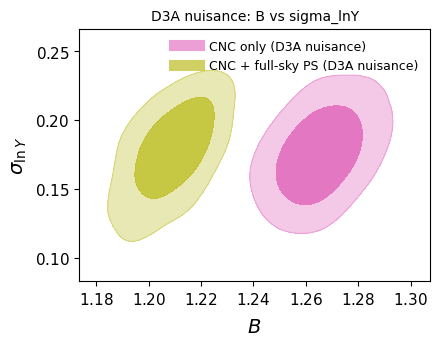

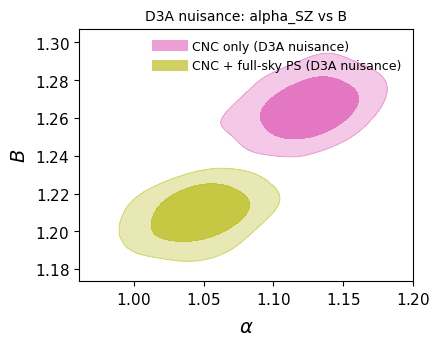

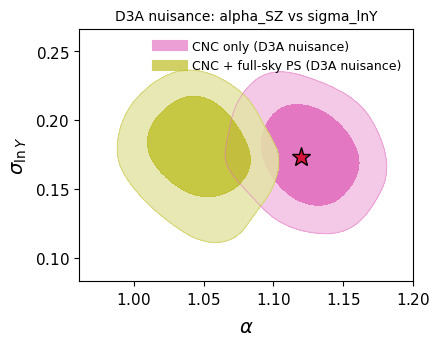

In [35]:
from matplotlib.lines import Line2D

if len(d3a_chains) >= 2:
    pairs = [
        ("B", "sigma_lnY", "d3a_B_sigma.pdf"),
        ("alpha_SZ", "B", "d3a_alpha_B.pdf"),
        ("alpha_SZ", "sigma_lnY", "d3a_alpha_sigma.pdf"),
    ]
    for x, y, fname in pairs:
        g2d = plots.get_single_plotter(width_inch=4.5)
        g2d.plot_2d(d3a_chains, x, y, filled=True, colors=d3a_colors)
        ax = g2d.get_axes()
        if x in TRUTH and y in TRUTH:
            ax.plot(TRUTH[x], TRUTH[y], "*", color="crimson", ms=14, mec="k", zorder=5)
        handles = [
            Line2D([], [], color=c, lw=8, alpha=0.7, label=l)
            for c, l in zip(d3a_colors, d3a_labels)
        ]
        ax.legend(handles=handles, fontsize=9, loc="best", frameon=False)
        ax.set_title(f"D3A nuisance: {x} vs {y}", fontsize=10)
        g2d.export(os.path.join(OUTDIR, fname))
        g2d.export(os.path.join(OUTDIR, fname.replace(".pdf", ".png", dpi=300)))
        plt.show()
else:
    print("D3A 2D panels skipped.")


## D3A fixed, B=1.35 CNC selection: nuisance posteriors

Same nuisance-only setup as above, but CNC counts from the B=1.35 selection catalogue (N(q>5)=768). Full-sky PS data unchanged.

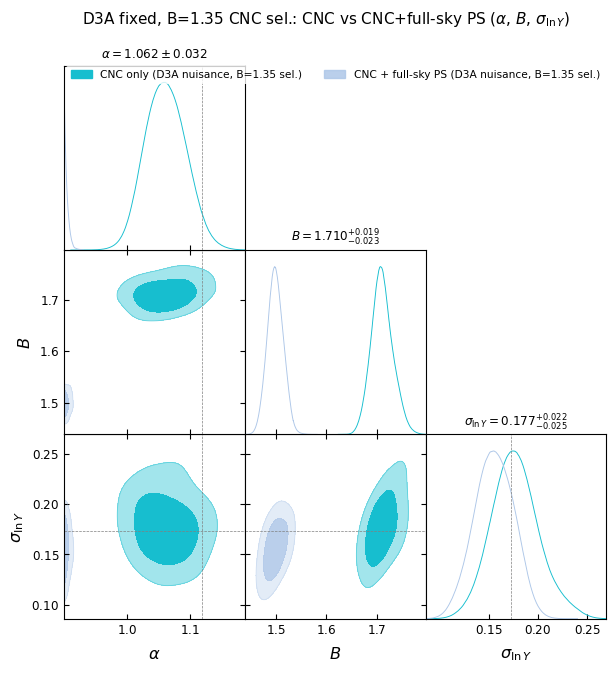

In [36]:
if len(d3a_b135_chains) >= 2 and d3a_b135_pars:
    g_d3a_b135 = plots.get_subplot_plotter(width_inch=7)
    g_d3a_b135.settings.legend_fontsize = 10
    g_d3a_b135.settings.figure_legend_frame = False
    d3a_b135_truth = {k: TRUTH[k] for k in d3a_b135_pars if k in TRUTH}
    g_d3a_b135.triangle_plot(
        d3a_b135_chains, d3a_b135_pars, filled=True, contour_colors=d3a_b135_colors,
        legend_labels=d3a_b135_labels, legend_loc="upper center", legend_ncol=2,
        title_limit=1, markers=d3a_b135_truth,
    )
    g_d3a_b135.fig.suptitle(
        r"D3A fixed, B=1.35 CNC sel.: CNC vs CNC+full-sky PS ($\alpha$, $B$, $\sigma_{\ln Y}$)",
        fontsize=11,
    )
    g_d3a_b135.fig.subplots_adjust(top=0.90)
    g_d3a_b135.export(os.path.join(OUTDIR, "d3a_b135_nuisance_triangle.pdf"))
    g_d3a_b135.export(os.path.join(OUTDIR, "d3a_b135_nuisance_triangle.png", dpi=300))
    plt.show()
else:
    print("D3A B135 nuisance triangle skipped (need both B135 d3aNuisance chains).")


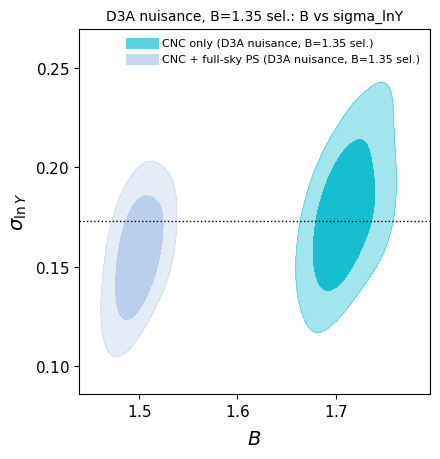

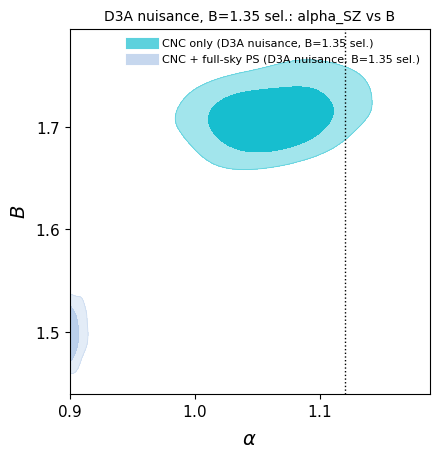

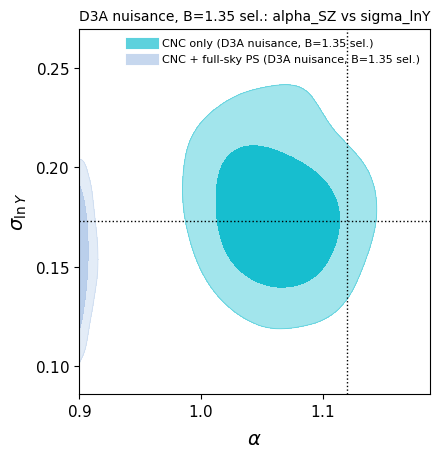

In [37]:
from matplotlib.lines import Line2D

if len(d3a_b135_chains) >= 2:
    pairs = [
        ("B", "sigma_lnY", "d3a_b135_B_sigma.pdf"),
        ("alpha_SZ", "B", "d3a_b135_alpha_B.pdf"),
        ("alpha_SZ", "sigma_lnY", "d3a_b135_alpha_sigma.pdf"),
    ]
    for x, y, fname in pairs:
        g2d = plots.get_subplot_plotter(width_inch=4.5, scaling=False)
        g2d.plot_2d(d3a_b135_chains, x, y, filled=True, colors=d3a_b135_colors)
        ax = plt.gca()
        if x in TRUTH and y in TRUTH:
            ax.axvline(TRUTH[x], color="k", ls=":", lw=1)
            ax.axhline(TRUTH[y], color="k", ls=":", lw=1)
        handles = [
            Line2D([], [], color=c, lw=8, alpha=0.7, label=l)
            for c, l in zip(d3a_b135_colors, d3a_b135_labels)
        ]
        ax.legend(handles=handles, frameon=False, fontsize=8, loc="best")
        ax.set_title(f"D3A nuisance, B=1.35 sel.: {x} vs {y}", fontsize=10)
        g2d.export(os.path.join(OUTDIR, fname))
        g2d.export(os.path.join(OUTDIR, fname.replace(".pdf", ".png", dpi=300)))
        plt.show()
else:
    print("D3A B135 2D panels skipped.")
